## 10.04 Bahdanau 注意力

### 环境配置

In [1]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu").setLevel(logging.WARNING)
import os
import sys
sys.path.insert(0, "..")
os.environ["TILE_FWK_DEVICE_ID"] = "0"
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    import pypto
    import math
    import torch
    from torch import nn
    import torch_npu

warnings.filterwarnings("ignore", message="Permission mismatch")
warnings.filterwarnings("ignore", message="TASK_QUEUE_ENABLE")
warnings.filterwarnings("ignore", message="On the interactive interface")
warnings.filterwarnings("ignore", message="Cannot create tensor")

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"
pypto.pypto_impl.DeviceInit()

from src.utils import (Encoder, Decoder, EncoderDecoder, load_data_nmt,
                       train_seq2seq, predict_seq2seq, bleu, sequence_mask,
                       show_heatmaps)
from src.pypto_ops import PyPTOGRU, PyPTOLSTM, PyPTOLinear
from src.pypto_ops import PyPTOBMM, PyPTOSoftmax, PyPTOTanh

torch.manual_seed(0)


def masked_softmax_torch(X, valid_lens):
    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)
    shape = X.shape
    if valid_lens.dim() == 1:
        valid_lens = torch.repeat_interleave(valid_lens, shape[1])
    else:
        valid_lens = valid_lens.reshape(-1)
    X = sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e6)
    return nn.functional.softmax(X.reshape(shape), dim=-1)


def masked_softmax_pypto(X, valid_lens):
    if valid_lens is None:
        return PyPTOSoftmax.apply(X)
    shape = X.shape
    if valid_lens.dim() == 1:
        valid_lens = torch.repeat_interleave(valid_lens, shape[1])
    else:
        valid_lens = valid_lens.reshape(-1)
    X = sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e6)
    return PyPTOSoftmax.apply(X.reshape(shape))


class AdditiveAttention(nn.Module):
    def __init__(self, key_size, query_size, num_hiddens, dropout, **kwargs):
        super().__init__(**kwargs)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=False)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=False)
        self.w_v = nn.Linear(num_hiddens, 1, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens):
        queries, keys = self.W_q(queries), self.W_k(keys)
        features = queries.unsqueeze(2) + keys.unsqueeze(1)
        features = torch.tanh(features)
        scores = self.w_v(features).squeeze(-1)
        self.attention_weights = masked_softmax_torch(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)


class DotProductAttention(nn.Module):
    def __init__(self, dropout, **kwargs):
        super().__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d)
        self.attention_weights = masked_softmax_torch(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)


class Seq2SeqEncoder(Encoder):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                 dropout=0, **kwargs):
        super().__init__(**kwargs)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size, num_hiddens, num_layers, dropout=dropout)

    def forward(self, X, *args):
        X = self.embedding(X).permute(1, 0, 2)
        output, state = self.rnn(X)
        return output, state


class Seq2SeqAttentionDecoder(Decoder):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                 dropout=0, attention=None, **kwargs):
        super().__init__(**kwargs)
        self.attention = attention or AdditiveAttention(
            num_hiddens, num_hiddens, num_hiddens, dropout)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size + num_hiddens, num_hiddens, num_layers,
                          dropout=dropout)
        self.dense = nn.Linear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens, *args):
        outputs, hidden_state = enc_outputs
        return (outputs.permute(1, 0, 2), hidden_state, enc_valid_lens)

    def forward(self, X, state):
        enc_outputs, hidden_state, enc_valid_lens = state
        X = self.embedding(X).permute(1, 0, 2)
        outputs, self._attention_weights = [], []
        for x in X:
            query = torch.unsqueeze(hidden_state[-1], dim=1)
            context = self.attention(query, enc_outputs, enc_outputs,
                                     enc_valid_lens)
            x = torch.cat((context, torch.unsqueeze(x, dim=1)), dim=-1)
            out, hidden_state = self.rnn(x.permute(1, 0, 2), hidden_state)
            outputs.append(out)
            self._attention_weights.append(self.attention.attention_weights)
        outputs = self.dense(torch.cat(outputs, dim=0))
        return outputs.permute(1, 0, 2), [enc_outputs, hidden_state,
                                          enc_valid_lens]

    @property
    def attention_weights(self):
        return self._attention_weights

### 练习 10.4.1

**题目：** 在实验中用LSTM替换GRU。

**解答：** LSTM 与 GRU 的替换点有两个：

1. **编码器**：`nn.GRU` → `nn.LSTM`（状态变为 `(H, C)` 二元组）；
2. **解码器**：`nn.GRU` → `nn.LSTM`，同时解码器状态从 `hidden_state`（单张量）变为 `(H_stack, C_stack)` 二元组，查询需要取 `H_stack[-1]`，RNN 调用与状态更新都要相应解包/打包。

LSTM 相比 GRU 多一个记忆元 $\mathbf{C}_t$ 和输入/遗忘/输出三个门，参数量更大、单步计算更多，因此训练略慢；但更强的门控通常带来更好的长距离依赖建模。下面先用 torch 训练一个 LSTM 版 Bahdanau 模型（缩减为 50 个迭代周期以演示替换效果，完整收敛需 250 个周期）。

以下使用 `torch` 编程进行验证：

loss 0.018, 5847.7 tokens/sec on npu:0
go . => va !, bleu 1.000
i lost . => j'ai perdu ., bleu 1.000
he's calm . => il court ., bleu 0.000
i'm home . => je suis chez moi ., bleu 1.000


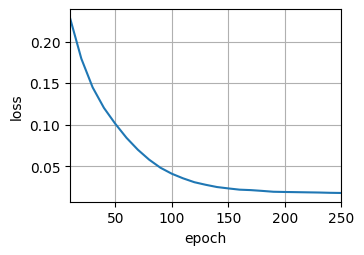

In [2]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu").setLevel(logging.WARNING)
class Seq2SeqEncoderLSTM(Encoder):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                 dropout=0, **kwargs):
        super().__init__(**kwargs)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.LSTM(embed_size, num_hiddens, num_layers,
                           dropout=dropout)

    def forward(self, X, *args):
        X = self.embedding(X).permute(1, 0, 2)
        output, state = self.rnn(X)   # state: (H, C)
        return output, state


class Seq2SeqAttentionDecoderLSTM(Decoder):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                 dropout=0, **kwargs):
        super().__init__(**kwargs)
        self.attention = AdditiveAttention(
            num_hiddens, num_hiddens, num_hiddens, dropout)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.LSTM(embed_size + num_hiddens, num_hiddens, num_layers,
                           dropout=dropout)
        self.dense = nn.Linear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens, *args):
        outputs, (H, C) = enc_outputs
        return (outputs.permute(1, 0, 2), (H, C), enc_valid_lens)

    def forward(self, X, state):
        enc_outputs, (H, C), enc_valid_lens = state
        X = self.embedding(X).permute(1, 0, 2)
        outputs, self._attention_weights = [], []
        for x in X:
            query = torch.unsqueeze(H[-1], dim=1)
            context = self.attention(query, enc_outputs, enc_outputs,
                                     enc_valid_lens)
            x = torch.cat((context, torch.unsqueeze(x, dim=1)), dim=-1)
            out, (H, C) = self.rnn(x.permute(1, 0, 2), (H, C))
            outputs.append(out)
            self._attention_weights.append(self.attention.attention_weights)
        outputs = self.dense(torch.cat(outputs, dim=0))
        return outputs.permute(1, 0, 2), [enc_outputs, (H, C),
                                          enc_valid_lens]

    @property
    def attention_weights(self):
        return self._attention_weights


embed_size, num_hiddens, num_layers, dropout = 32, 32, 2, 0.1
batch_size, num_steps = 64, 10
lr, num_epochs = 0.005, 250

train_iter, src_vocab, tgt_vocab = load_data_nmt(batch_size, num_steps)
encoder = Seq2SeqEncoderLSTM(len(src_vocab), embed_size, num_hiddens,
                             num_layers, dropout)
decoder = Seq2SeqAttentionDecoderLSTM(len(tgt_vocab), embed_size, num_hiddens,
                                      num_layers, dropout)
net = EncoderDecoder(encoder, decoder)
train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device)

engs = ['go .', "i lost .", 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']
for eng, fra in zip(engs, fras):
    translation, _ = predict_seq2seq(net, eng, src_vocab, tgt_vocab,
                                     num_steps, device)
    print(f'{eng} => {translation}, bleu {bleu(translation, fra, k=2):.3f}')

使用 `PyPTO` 编程进行验证（`PyPTOLSTM` 替换 `PyPTOGRU`，接口与 `nn.LSTM` 一致）：

loss 0.024, 622.1 tokens/sec on npu:0


go . => va !, bleu 1.000
i lost . => j'ai perdu ., bleu 1.000


he's calm . => il est paresseux ., bleu 0.658
i'm home . => je suis chez moi ., bleu 1.000


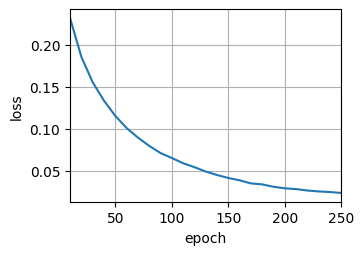

In [3]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu").setLevel(logging.WARNING)
class Seq2SeqEncoderLSTMPypto(Encoder):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                 dropout=0, **kwargs):
        super().__init__(**kwargs)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = PyPTOLSTM(embed_size, num_hiddens, num_layers,
                             dropout=dropout)

    def forward(self, X, *args):
        X = self.embedding(X).permute(1, 0, 2).contiguous()
        output, state = self.rnn(X)   # state: (H, C) 二元组
        return output, state


class Seq2SeqAttentionDecoderLSTMPypto(Decoder):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                 dropout=0, **kwargs):
        super().__init__(**kwargs)
        self.attention = AdditiveAttentionPypto(
            num_hiddens, num_hiddens, num_hiddens, dropout)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = PyPTOLSTM(embed_size + num_hiddens, num_hiddens,
                             num_layers, dropout=dropout)
        self.dense = PyPTOLinear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens, *args):
        outputs, (H, C) = enc_outputs
        return (outputs.permute(1, 0, 2), (H, C), enc_valid_lens)

    def forward(self, X, state):
        enc_outputs, (H, C), enc_valid_lens = state
        X = self.embedding(X).permute(1, 0, 2)
        outputs, self._attention_weights = [], []
        for x in X:
            query = torch.unsqueeze(H[-1], dim=1)
            context = self.attention(query, enc_outputs, enc_outputs,
                                     enc_valid_lens)
            x = torch.cat((context, torch.unsqueeze(x, dim=1)), dim=-1)
            out, (H, C) = self.rnn(x.permute(1, 0, 2).contiguous(), (H, C))
            outputs.append(out)
            self._attention_weights.append(self.attention.attention_weights)
        outputs = self.dense(torch.cat(outputs, dim=0))
        return outputs.permute(1, 0, 2), [enc_outputs, (H, C),
                                          enc_valid_lens]

    @property
    def attention_weights(self):
        return self._attention_weights


class AdditiveAttentionPypto(nn.Module):
    def __init__(self, key_size, query_size, num_hiddens, dropout, **kwargs):
        super().__init__(**kwargs)
        self.W_k = PyPTOLinear(key_size, num_hiddens, bias=False)
        self.W_q = PyPTOLinear(query_size, num_hiddens, bias=False)
        self.w_v = PyPTOLinear(num_hiddens, 1, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens):
        queries, keys = self.W_q(queries), self.W_k(keys)
        features = queries.unsqueeze(2) + keys.unsqueeze(1)
        features = PyPTOTanh.apply(features)
        scores = self.w_v(features).squeeze(-1)
        self.attention_weights = masked_softmax_pypto(scores, valid_lens)
        return PyPTOBMM.apply(self.dropout(self.attention_weights), values)


encoder = Seq2SeqEncoderLSTMPypto(len(src_vocab), embed_size, num_hiddens,
                                  num_layers, dropout)
decoder = Seq2SeqAttentionDecoderLSTMPypto(len(tgt_vocab), embed_size,
                                           num_hiddens, num_layers, dropout)
net = EncoderDecoder(encoder, decoder)
train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device)

for eng, fra in zip(engs, fras):
    translation, _ = predict_seq2seq(net, eng, src_vocab, tgt_vocab,
                                     num_steps, device)
    print(f'{eng} => {translation}, bleu {bleu(translation, fra, k=2):.3f}')

### 练习 10.4.2

**题目：** 修改实验以将加性注意力打分函数替换为缩放点积注意力，它如何影响训练效率？

**解答：** 在 Bahdanau 解码器中，查询是解码器隐状态（长度 `num_hiddens`），键是编码器隐状态（长度 `num_hiddens`），两者同维，可以直接使用 [10.3 节](../10.03_attention_scoring_functions.ipynb)的缩放点积注意力。影响：

- **参数更少**：加性注意力含 $W_q, W_k, w_v$ 三组可学习参数，缩放点积注意力无参数；
- **计算更少**：点积评分只需一次批量矩阵乘法（`queries @ keys^T`），加性注意力需两次线性投影 + 广播求和 + tanh + 一次线性投影；
- 因此训练效率更高（每步前向/反向更快），但打分函数表达力更弱，最终精度可能略低。

下面训练缩放点积注意力版模型（50 个周期演示）。

以下使用 `torch` 编程进行验证：

loss 0.020, 837.4 tokens/sec on npu:0
go . => va !, bleu 1.000
i lost . => j'ai perdu ., bleu 1.000


he's calm . => j'ai va ., bleu 0.000
i'm home . => je suis chez moi ., bleu 1.000


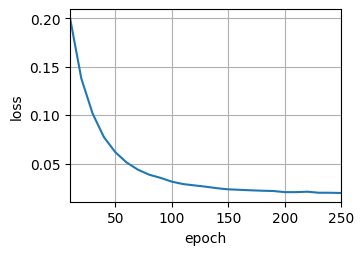

In [4]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu").setLevel(logging.WARNING)
# 注意：本 NPU 环境的 torch nn.GRU（FP32）不支持（DynamicGRUV2 算子缺失），
# 因此编码器/解码器的 RNN 使用 PyPTOGRU（第 9 章算子），
# 注意力打分函数仍用 torch 实现（DotProductAttention），以对比加性/点积注意力。
class Seq2SeqEncoderGRUPypto(Encoder):
    """GRU 编码器（PyPTOGRU 替代 nn.GRU）"""

    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                 dropout=0, **kwargs):
        super().__init__(**kwargs)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = PyPTOGRU(embed_size, num_hiddens, num_layers,
                            dropout=dropout)

    def forward(self, X, *args):
        X = self.embedding(X).permute(1, 0, 2).contiguous()
        output, state = self.rnn(X)
        return output, state


class Seq2SeqAttentionDecoderGRUPypto(Decoder):
    """解码器（PyPTOGRU + torch DotProductAttention + PyPTOLinear）"""

    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                 dropout=0, **kwargs):
        super().__init__(**kwargs)
        self.attention = DotProductAttention(dropout)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = PyPTOGRU(embed_size + num_hiddens, num_hiddens,
                            num_layers, dropout=dropout)
        self.dense = PyPTOLinear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens, *args):
        outputs, hidden_state = enc_outputs
        return (outputs.permute(1, 0, 2), hidden_state, enc_valid_lens)

    def forward(self, X, state):
        enc_outputs, hidden_state, enc_valid_lens = state
        X = self.embedding(X).permute(1, 0, 2)
        outputs, self._attention_weights = [], []
        for x in X:
            query = torch.unsqueeze(hidden_state[-1], dim=1)
            context = self.attention(query, enc_outputs, enc_outputs,
                                     enc_valid_lens)
            x = torch.cat((context, torch.unsqueeze(x, dim=1)), dim=-1)
            out, hidden_state = self.rnn(x.permute(1, 0, 2).contiguous(),
                                         hidden_state)
            outputs.append(out)
            self._attention_weights.append(self.attention.attention_weights)
        outputs = self.dense(torch.cat(outputs, dim=0))
        return outputs.permute(1, 0, 2), [enc_outputs, hidden_state,
                                          enc_valid_lens]

    @property
    def attention_weights(self):
        return self._attention_weights


encoder = Seq2SeqEncoderGRUPypto(len(src_vocab), embed_size, num_hiddens,
                                 num_layers, dropout)
decoder = Seq2SeqAttentionDecoderGRUPypto(
    len(tgt_vocab), embed_size, num_hiddens, num_layers, dropout)
net = EncoderDecoder(encoder, decoder)
train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device)

for eng, fra in zip(engs, fras):
    translation, _ = predict_seq2seq(net, eng, src_vocab, tgt_vocab,
                                     num_steps, device)
    print(f'{eng} => {translation}, bleu {bleu(translation, fra, k=2):.3f}')

使用 `PyPTO` 编程进行验证：

loss 0.019, 718.0 tokens/sec on npu:0


go . => va !, bleu 1.000
i lost . => j'ai perdu ., bleu 1.000


he's calm . => il est bon ., bleu 0.658
i'm home . => je suis chez moi ., bleu 1.000


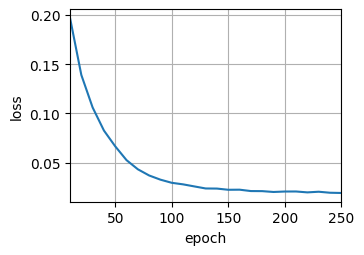

In [5]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu").setLevel(logging.WARNING)
class Seq2SeqEncoderPypto(Encoder):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                 dropout=0, **kwargs):
        super().__init__(**kwargs)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = PyPTOGRU(embed_size, num_hiddens, num_layers,
                            dropout=dropout)

    def forward(self, X, *args):
        X = self.embedding(X).permute(1, 0, 2).contiguous()
        output, state = self.rnn(X)
        return output, state


class DotProductAttentionPypto(nn.Module):
    def __init__(self, dropout, **kwargs):
        super().__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        scores = PyPTOBMM.apply(queries, keys.transpose(1, 2)) / math.sqrt(d)
        self.attention_weights = masked_softmax_pypto(scores, valid_lens)
        return PyPTOBMM.apply(self.dropout(self.attention_weights), values)


class DotProductAttentionDecoderPypto(nn.Module):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                 dropout=0, **kwargs):
        super().__init__(**kwargs)
        self.attention = DotProductAttentionPypto(dropout)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = PyPTOGRU(embed_size + num_hiddens, num_hiddens, num_layers,
                            dropout=dropout)
        self.dense = PyPTOLinear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens, *args):
        outputs, hidden_state = enc_outputs
        return (outputs.permute(1, 0, 2), hidden_state, enc_valid_lens)

    def forward(self, X, state):
        enc_outputs, hidden_state, enc_valid_lens = state
        X = self.embedding(X).permute(1, 0, 2)
        outputs, self._attention_weights = [], []
        for x in X:
            query = torch.unsqueeze(hidden_state[-1], dim=1)
            context = self.attention(query, enc_outputs, enc_outputs,
                                     enc_valid_lens)
            x = torch.cat((context, torch.unsqueeze(x, dim=1)), dim=-1)
            out, hidden_state = self.rnn(x.permute(1, 0, 2).contiguous(),
                                         hidden_state)
            outputs.append(out)
            self._attention_weights.append(self.attention.attention_weights)
        outputs = self.dense(torch.cat(outputs, dim=0))
        return outputs.permute(1, 0, 2), [enc_outputs, hidden_state,
                                          enc_valid_lens]

    @property
    def attention_weights(self):
        return self._attention_weights


encoder = Seq2SeqEncoderPypto(len(src_vocab), embed_size, num_hiddens,
                              num_layers, dropout)
decoder = DotProductAttentionDecoderPypto(len(tgt_vocab), embed_size,
                                          num_hiddens, num_layers, dropout)
net = EncoderDecoder(encoder, decoder)
train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device)

for eng, fra in zip(engs, fras):
    translation, _ = predict_seq2seq(net, eng, src_vocab, tgt_vocab,
                                     num_steps, device)
    print(f'{eng} => {translation}, bleu {bleu(translation, fra, k=2):.3f}')

---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#/](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/)